In [5]:
# ==============================
# 1. IMPORT THƯ VIỆN
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pmdarima import auto_arima

# ==============================
# 2. LOAD & CHUẨN BỊ DỮ LIỆU
# ==============================
df = pd.read_excel("data.xlsx")

# Tạo biến policy (có variation)
df['Policy'] = np.where(df['Year'] >= 1993, 1, 0)

# Lọc giai đoạn nghiên cứu
df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()

# Xóa missing
df = df.dropna(subset=['TF', 'UP', 'Policy'])


In [9]:
# ==============================
# 1. OLS
# ==============================
X = df[['Policy', 'UP']]
X = sm.add_constant(X)

y = df['TF']

model_ols = sm.OLS(y, X).fit()
beta_policy = model_ols.params['Policy']

# Residual = phần KHÔNG có policy
df['residual'] = model_ols.resid

# ==============================
# 2. ARIMA trên residual
# ==============================
model_arima = auto_arima(
    df['residual'],
    d=1,
    max_d=1,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)

future_years = np.arange(2024, 2031)
residual_forecast = model_arima.predict(n_periods=7)

# ==============================
# 3. Forecast UP
# ==============================
last_5_up = df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
last_up = df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# ==============================
# 4. Rebuild TFR đúng cách
# ==============================
policy_continue = np.array([1,1,1,1,1,1,1])
policy_remove   = np.array([1,1,0,0,0,0,0])

# baseline từ OLS (KHÔNG policy)
beta0 = model_ols.params['const']
beta_up = model_ols.params['UP']

base_part = beta0 + beta_up * np.array(future_up)

# Forecast đúng
# Kiểm tra ý nghĩa thống kê
pval = model_ols.pvalues['Policy']

print("\nP-value Policy =", pval)

beta0 = model_ols.params['const']
beta_up = model_ols.params['UP']

base_part = beta0 + beta_up * np.array(future_up)

if pval < 0.05:
    print("Policy có ý nghĩa → giữ trong forecast")
    
    forecast_continue = base_part + beta_policy * policy_continue + residual_forecast
    forecast_remove   = base_part + beta_policy * policy_remove   + residual_forecast
else:
    print("Policy KHÔNG có ý nghĩa → loại khỏi forecast")
    
    forecast_continue = base_part + residual_forecast
    forecast_remove   = base_part + residual_forecast


P-value Policy = 4.829670133077072e-07
Policy có ý nghĩa → giữ trong forecast



--- KỊCH BẢN TIẾP TỤC ---
 Năm  Policy     UP   TFR
2024       1 39.006 1.879
2025       1 39.883 1.844
2026       1 40.759 1.810
2027       1 41.636 1.775
2028       1 42.512 1.741
2029       1 43.389 1.706
2030       1 44.265 1.672

--- KỊCH BẢN BÃI BỎ ---
 Năm  Policy     UP   TFR
2024       1 39.006 1.879
2025       1 39.883 1.844
2026       0 40.759 2.845
2027       0 41.636 2.810
2028       0 42.512 2.776
2029       0 43.389 2.742
2030       0 44.265 2.707

--- SO SÁNH ---
 Năm  TFR_Continue  TFR_Remove  Diff
2024         1.879       1.879 0.000
2025         1.844       1.844 0.000
2026         1.810       2.845 1.035
2027         1.775       2.810 1.035
2028         1.741       2.776 1.035
2029         1.706       2.742 1.035
2030         1.672       2.707 1.035


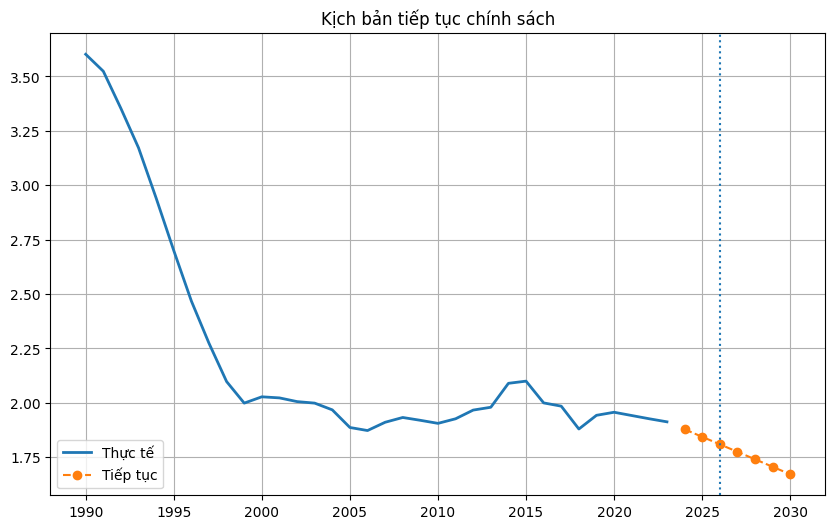

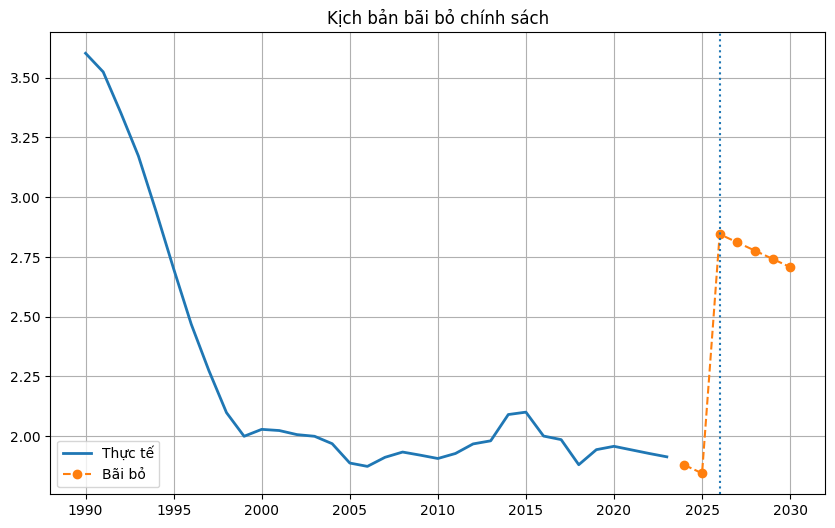

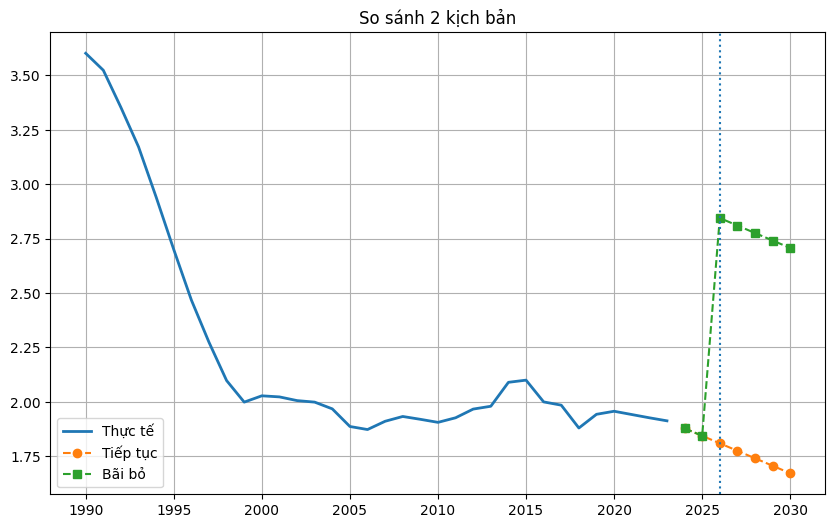

In [10]:
df_continue = pd.DataFrame({
    "Năm": future_years,
    "Policy": policy_continue,
    "UP": np.round(future_up, 3),
    "TFR": np.round(forecast_continue, 3)
})

df_remove = pd.DataFrame({
    "Năm": future_years,
    "Policy": policy_remove,
    "UP": np.round(future_up, 3),
    "TFR": np.round(forecast_remove, 3)
})

df_compare = pd.DataFrame({
    "Năm": future_years,
    "TFR_Continue": np.round(forecast_continue, 3),
    "TFR_Remove": np.round(forecast_remove, 3),
    "Diff": np.round(forecast_remove - forecast_continue, 3)
})

print("\n--- KỊCH BẢN TIẾP TỤC ---")
print(df_continue.to_string(index=False))

print("\n--- KỊCH BẢN BÃI BỎ ---")
print(df_remove.to_string(index=False))

print("\n--- SO SÁNH ---")
print(df_compare.to_string(index=False))

# ==============================
# 9. VẼ BIỂU ĐỒ
# ==============================

# --- Kịch bản 1
plt.figure(figsize=(10,6))
plt.plot(df['Year'], df['TF'], label='Thực tế', linewidth=2)
plt.plot(future_years, forecast_continue, '--o', label='Tiếp tục')
plt.axvline(x=2026, linestyle=':')
plt.title('Kịch bản tiếp tục chính sách')
plt.legend()
plt.grid(True)
plt.show()

# --- Kịch bản 2
plt.figure(figsize=(10,6))
plt.plot(df['Year'], df['TF'], label='Thực tế', linewidth=2)
plt.plot(future_years, forecast_remove, '--o', label='Bãi bỏ')
plt.axvline(x=2026, linestyle=':')
plt.title('Kịch bản bãi bỏ chính sách')
plt.legend()
plt.grid(True)
plt.show()

# --- So sánh
plt.figure(figsize=(10,6))
plt.plot(df['Year'], df['TF'], label='Thực tế', linewidth=2)
plt.plot(future_years, forecast_continue, '--o', label='Tiếp tục')
plt.plot(future_years, forecast_remove, '--s', label='Bãi bỏ')
plt.axvline(x=2026, linestyle=':')
plt.title('So sánh 2 kịch bản')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Kiểm tra ý nghĩa thống # Kiểm tra ý nghĩa thống kê
pval = model_ols.pvalues['Policy']

print("\nP-value Policy =", pval)

beta0 = model_ols.params['const']
beta_up = model_ols.params['UP']

base_part = beta0 + beta_up * np.array(future_up)

if pval < 0.05:
    print("Policy có ý nghĩa → giữ trong forecast")
    
    forecast_continue = base_part + beta_policy * policy_continue + residual_forecast
    forecast_remove   = base_part + beta_policy * policy_remove   + residual_forecast
else:
    print("Policy KHÔNG có ý nghĩa → loại khỏi forecast")
    
    forecast_continue = base_part + residual_forecast
    forecast_remove   = base_part + residual_forecast
pval = model_ols.pvalues['Policy']

print("\nP-value Policy =", pval)

beta0 = model_ols.params['const']
beta_up = model_ols.params['UP']

base_part = beta0 + beta_up * np.array(future_up)

if pval < 0.05:
    print("Policy có ý nghĩa → giữ trong forecast")
    
    forecast_continue = base_part + beta_policy * policy_continue + residual_forecast
    forecast_remove   = base_part + beta_policy * policy_remove   + residual_forecast
else:
    print("Policy KHÔNG có ý nghĩa → loại khỏi forecast")
    
    forecast_continue = base_part + residual_forecast
    forecast_remove   = base_part + residual_forecast


P-value Policy = 4.829670133077072e-07
Policy có ý nghĩa → giữ trong forecast

P-value Policy = 4.829670133077072e-07
Policy có ý nghĩa → giữ trong forecast
